In [11]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("wallet_features.csv")

In [13]:
df.shape

(31527, 13)

In [14]:
df.columns

Index(['wallet', 'tx_count', 'total_value_eth_sent',
       'total_value_eth_received', 'avg_gas', 'unique_recipients',
       'unique_senders', 'contract_call_ratio', 'tx_frequency',
       'tokens_sent_count', 'tokens_received_count', 'unique_tokens_sent',
       'unique_tokens_received'],
      dtype='str')

In [15]:
df.isna().sum()

wallet                      0
tx_count                    0
total_value_eth_sent        0
total_value_eth_received    0
avg_gas                     0
unique_recipients           0
unique_senders              0
contract_call_ratio         0
tx_frequency                0
tokens_sent_count           0
tokens_received_count       0
unique_tokens_sent          0
unique_tokens_received      0
dtype: int64

In [16]:
wallet_ids = df["wallet"]

X = df.drop(columns=["wallet"])

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Elbow Method

We use the elbow method to estimate the optimal number of clusters for K-Means clustering

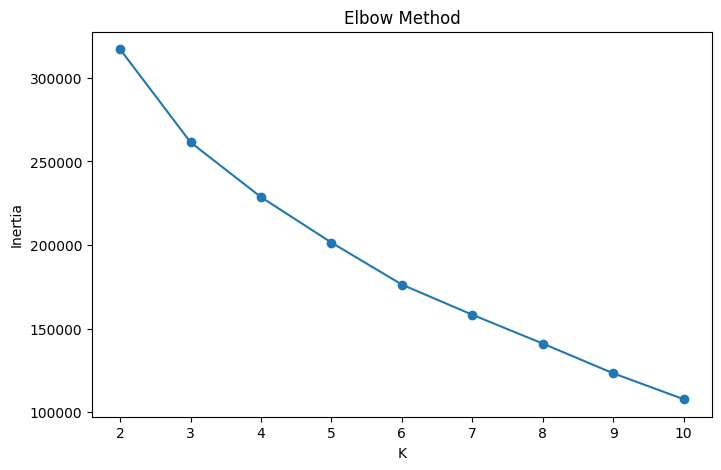

In [24]:
inertias = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K_range, inertias, marker='o')

plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

The elbow plot helps us decide how many clusters to use. As K gets bigger, inertia goes down because the wallets are split into more groups. In this plot, the drop is clear from K=2 to K=4, but after K=4 the line starts to flatten out more. So I used K=4 as a reasonable starting point for K-Means.

In [ ]:
## K-Means Clustering

We apply K-Means clustering to the standardized wallet feature matrix.

In [21]:
best_k = 4

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

In [22]:
cluster_summary = (
    df
    .drop(columns=["wallet"])
    .groupby("cluster")
    .mean()
)

cluster_summary

,tx_count,total_value_eth_sent,total_value_eth_received,avg_gas,unique_recipients,unique_senders,contract_call_ratio,tx_frequency,tokens_sent_count,tokens_received_count,unique_tokens_sent,unique_tokens_received
cluster,,,,,,,,,,,,
0,7.496843,4.358256,2.796338,273501.949421,2.856696,0.781639,0.961019,7.496843,3.921704,3.144238,1.581618,1.311920
1,753.973684,1108.774551,1049.287903,163148.523827,306.210526,133.657895,0.400660,753.973684,342.368421,178.500000,20.815789,11.684211
2,1.479018,12.084589,10.555694,13866.589679,1.064944,6.830784,0.070198,1.479018,13.382732,13.506894,1.942063,1.799066
3,0.000000,0.000000,3.971165,0.000000,0.000000,20.333333,0.000000,0.000000,10826.000000,8625.000000,593.000000,516.000000


## Cluster Interpretation

Based on the cluster summary, the K-Means model separates wallets into four main behavior groups.

### Cluster 0: Smart Contract-Heavy Wallets
These wallets do not have extremely high transaction counts, but they have a very high `contract_call_ratio` and high average gas usage. This suggests that their activity is mainly related to smart contract interactions rather than simple ETH transfers. These wallets may represent DeFi users, NFT users, staking wallets, or other DApp-related users.

### Cluster 1: High-Activity / Trading Wallets
This cluster has the highest transaction count, high ETH sent and received, and many unique recipients and senders. These wallets are much more active than the others and interact with many different addresses. This group may include active traders, trading bots, market makers, exchange-like wallets, or arbitrage wallets.

### Cluster 2: Low-Activity Retail Wallets
This cluster has very low transaction counts, low contract interaction, and only a small number of counterparties. These wallets look like casual or inactive users. They may represent normal retail wallets, simple holders, or wallets with only a few transactions.

### Cluster 3: Passive / Receive-Oriented Wallets
These wallets have little or no outgoing activity but receive value or interactions from multiple senders. This makes them different from normal low-activity wallets. They may represent passive holding wallets, deposit addresses, collection wallets, or edge cases created by the preprocessing process.

Overall, the clusters align with the project goal because they turn raw Ethereum wallet behavior into interpretable wallet archetypes.

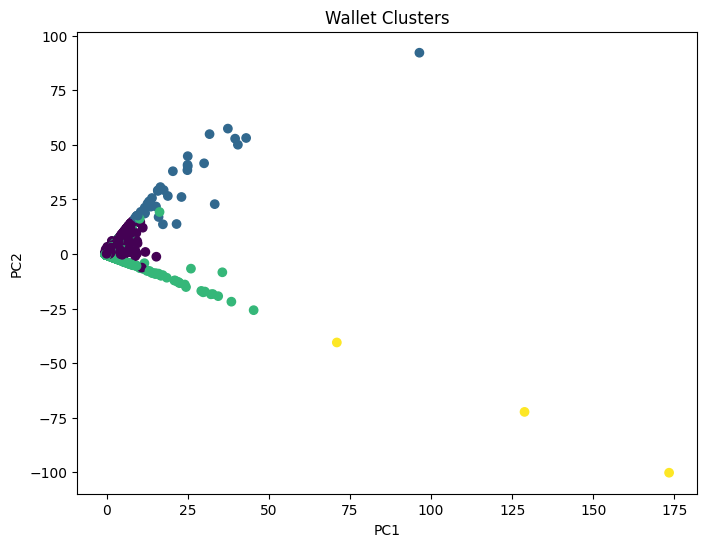

In [23]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["cluster"]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wallet Clusters")

plt.show()